# Background detection exploration

Goal is to determine if we can find parts of the image outside of the lane markers which can be used for fault detection.

Testing: 
- Horizon
- Foliage 
- Outer marking

In [13]:
import numpy as np
import cv2
import matplotlib.pyplot as plt


In [14]:
# Import images
im_fn = "/home/daniel-choate/Datasets/VTTI_airfield/MSNV_0000_0000_0_250804_1830_00156/6_fps/Images_TSR/frame_"
ims_len = 10 
ims_start = 26809
im_int = 10
images = {}
for i in range(ims_len):
    im = im_fn + str(ims_start + i*im_int) + '.jpg'
    images[i] = cv2.imread(im)

# print(images[0])

### Segment out the runway 
Looking to focus on area outside the runway

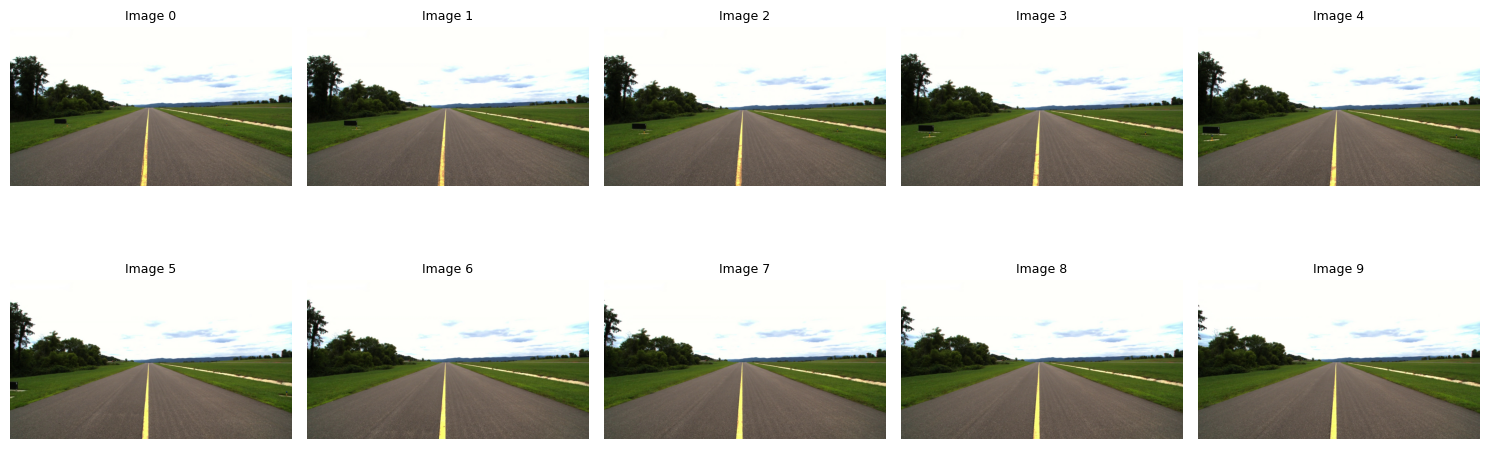

In [25]:
# List examples of a few images

ncols = 5
rows = int(np.ceil(len(images) / ncols))
fig, axs = plt.subplots(rows, ncols, figsize=(15, 3*rows), squeeze=False)

for ax in axs.flatten():
    ax.axis('off')

for imnum, ax in enumerate(axs.flatten()[:len(images)]):
    im = cv2.cvtColor(images[imnum], cv2.COLOR_BGR2RGB)
    ax.imshow(im)
    ax.set_title(f'Image {imnum}', fontsize=9)

plt.tight_layout()
plt.show()

In [5]:
# Load SAM2 image predictor
from sam2.sam2_image_predictor import SAM2ImagePredictor

device = "cuda" if torch.cuda.is_available() else "cpu"
predictor = SAM2ImagePredictor.from_pretrained("facebook/sam2.1-hiera-large", device=device)

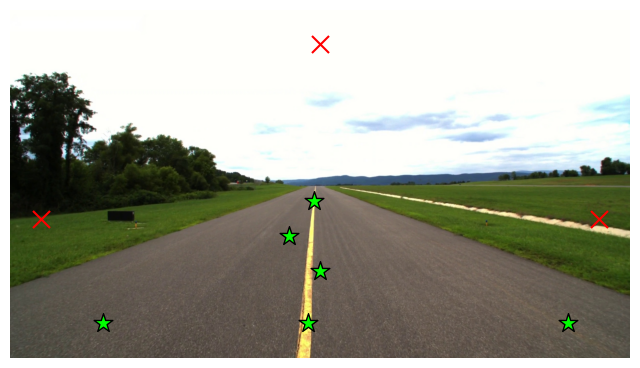

In [18]:
# Point prompts as fractions of (width, height) - adjust after checking the plot below
# label 1 = runway, 0 = not runway
pos_pts = [(0.48, 0.90), (0.50, 0.75), (0.45, 0.65), (0.49, 0.55), (0.9, 0.9), (0.15, 0.9)]
neg_pts = [(0.50, 0.10), (0.05, 0.60), (0.95, 0.60)]

def get_prompts(im):
    h, w = im.shape[:2]
    pts = np.array([(x*w, y*h) for x, y in pos_pts + neg_pts], dtype=np.float32)
    labels = np.array([1]*len(pos_pts) + [0]*len(neg_pts), dtype=np.int32)
    return pts, labels

# Show prompts on first image
im = cv2.cvtColor(images[0], cv2.COLOR_BGR2RGB)
pts, labels = get_prompts(im)
plt.figure(figsize=(8, 5))
plt.imshow(im)
plt.scatter(pts[labels == 1, 0], pts[labels == 1, 1], c='lime', marker='*', s=200, edgecolor='k')
plt.scatter(pts[labels == 0, 0], pts[labels == 0, 1], c='red', marker='x', s=150)
plt.axis('off')
plt.show()

In [19]:
# Segment runway in each image 
runway_masks = {}
with torch.inference_mode(), torch.autocast(device, dtype=torch.bfloat16):
    for i in range(len(images)):
        im = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)
        predictor.set_image(im)
        pts, labels = get_prompts(im) # Get prompts from each image 
        masks, scores, _ = predictor.predict(point_coords=pts, point_labels = labels, multimask_output=False)
        runway_masks[i] = masks[0].astype(bool)
        print(f'Image {i}: score {scores[0]:.3f}')

Image 0: score 0.984
Image 1: score 0.984
Image 2: score 0.988
Image 3: score 0.988
Image 4: score 0.988
Image 5: score 0.988
Image 6: score 0.988
Image 7: score 0.988
Image 8: score 0.988
Image 9: score 0.984


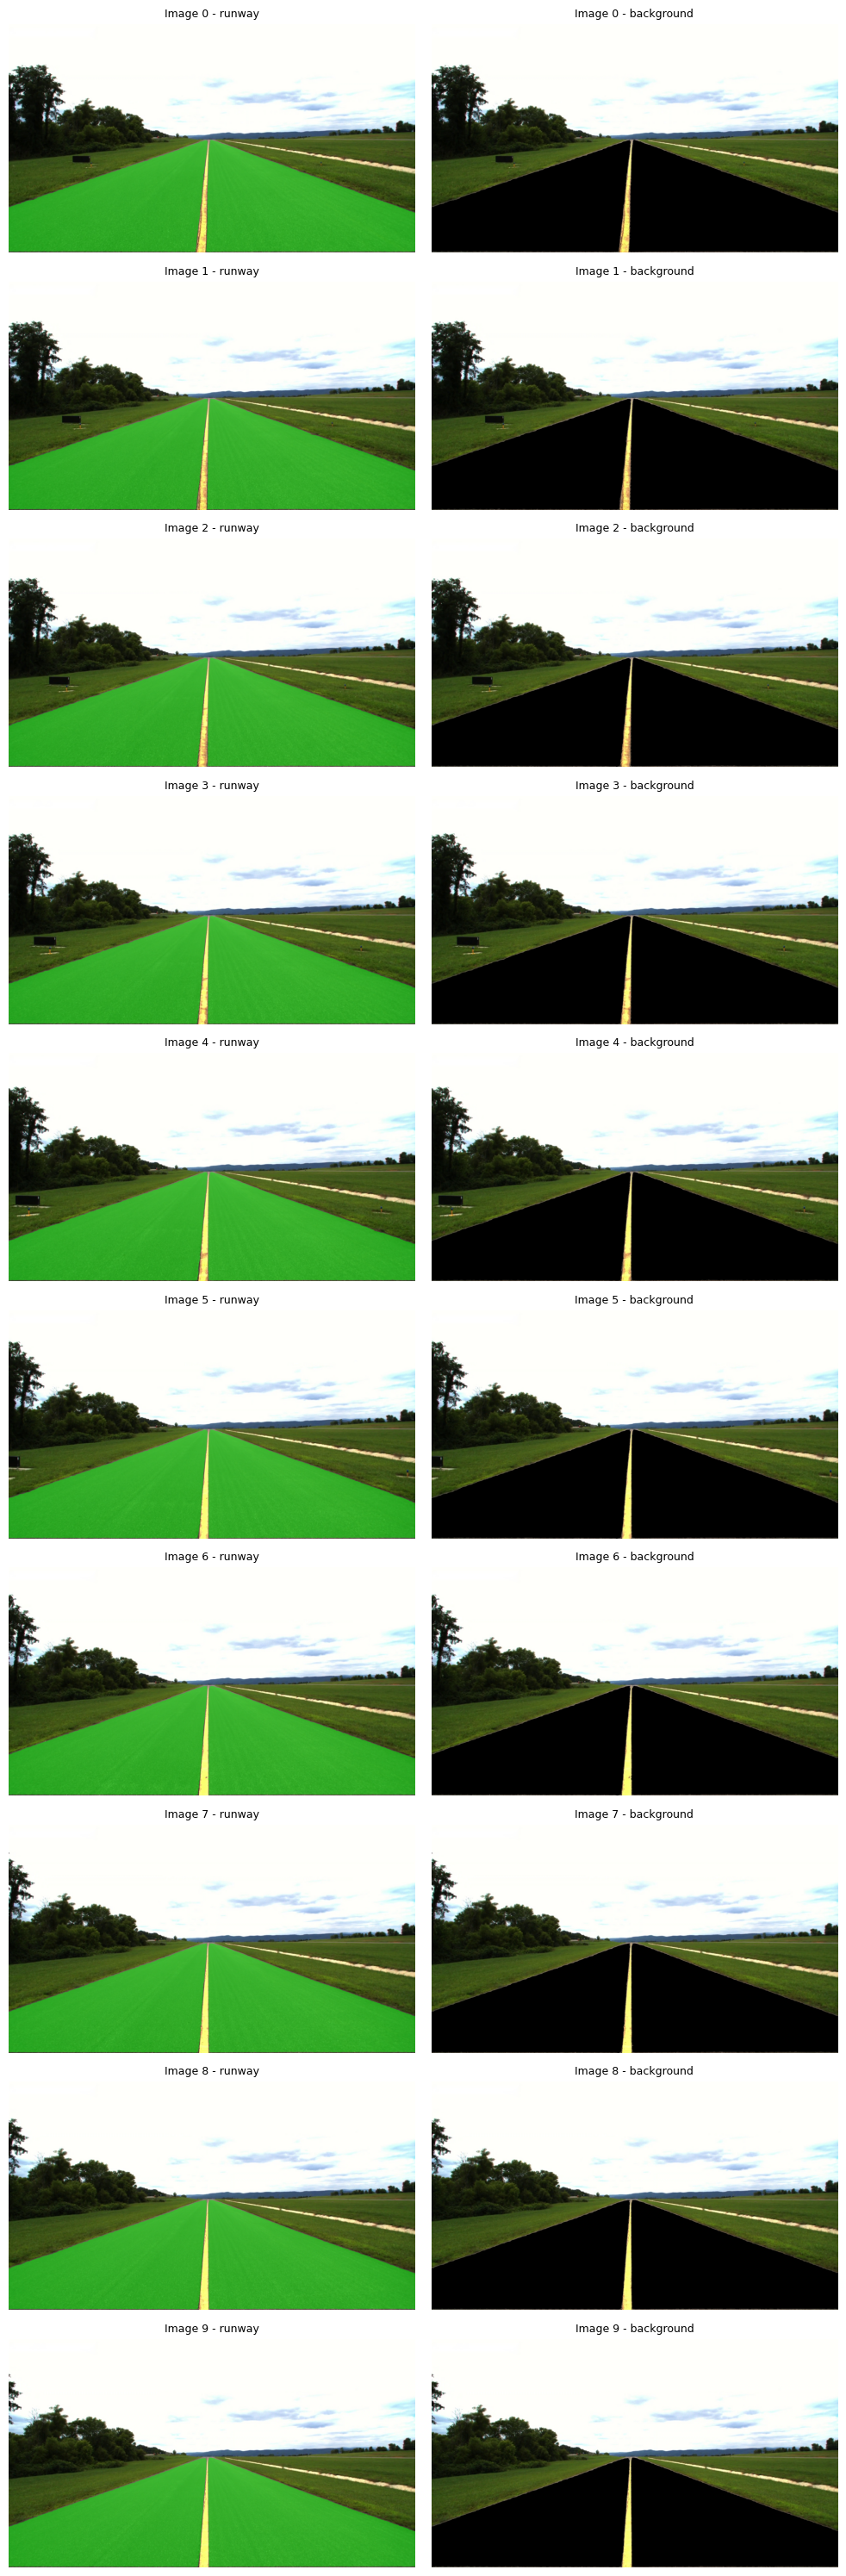

In [20]:
# Show runway (green) and background outside runway 
fig, axs = plt.subplots(len(images), 2, figsize=(10, 3*len(images)), squeeze=False)
for i in range(len(images)):
    im = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)
    overlay = im.copy()
    overlay[runway_masks[i]] = (0.5*overlay[runway_masks[i]] + 0.5*np.array([0,255,0])).astype(np.uint8)
    background = im * ~runway_masks[i][..., None] # ~ is NOT for boolean arrays 
    axs[i, 0].imshow(overlay)
    axs[i, 0].set_title(f"Image {i} - runway", fontsize=9)
    axs[i, 1].imshow(background)
    axs[i, 1].set_title(f"Image {i} - background", fontsize=9)

for ax in axs.flatten():
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Segment runway in each image
runway_masks = {}
with torch.inference_mode(), torch.autocast(device, dtype=torch.bfloat16):
    for i in range(len(images)):
        im = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)
        predictor.set_image(im)
        pts, labels = get_prompts(im)
        masks, scores, _ = predictor.predict(point_coords=pts, point_labels=labels, multimask_output=False)
        runway_masks[i] = masks[0].astype(bool)
        print(f'Image {i}: score {scores[0]:.3f}')

# Show runway (green) and background (outside runway)
fig, axs = plt.subplots(len(images), 2, figsize=(10, 3*len(images)), squeeze=False)
for i in range(len(images)):
    im = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)
    overlay = im.copy()
    overlay[runway_masks[i]] = (0.5*overlay[runway_masks[i]] + 0.5*np.array([0, 255, 0])).astype(np.uint8)
    background = im * ~runway_masks[i][..., None]
    axs[i, 0].imshow(overlay)
    axs[i, 0].set_title(f'Image {i} - runway', fontsize=9)
    axs[i, 1].imshow(background)
    axs[i, 1].set_title(f'Image {i} - background', fontsize=9)
for ax in axs.flatten():
    ax.axis('off')
plt.tight_layout()
plt.show()